# Assignment 3 — From Raw Signals to a Lean Feature Set

**Course:** Feature Engineering & MLOps  
**Assignment:** 3  
**Phase 3:** Time-based Features & Feature Creation  
**Phase 4:** Feature Selection

## Objective
Engineer lag, rolling-window, cyclical, trend, and interaction features from the daily institute-performance data, then apply **filter**, **wrapper**, and **embedded** feature-selection methods to the resulting candidate feature set. The notebook uses evidence from the dataset to determine what survives selection and whether the three selection families agree.

## 1. Load, Inspect, and Sort the Daily Dataset


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

DATA_PATH = Path("data/raw/daily_batch_performance.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/mnt/data/daily_batch_performance.csv")
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)

print(f"Dataset shape: {df.shape}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print("\nColumns:")
print(df.columns.tolist())
display(df.head())

Dataset shape: (730, 10)
Date range: 2024-01-01 to 2025-12-30

Columns:
['date', 'marketing_spend', 'discount_pct', 'website_visits', 'website_visits_copy', 'competitor_promo_flag', 'is_holiday', 'random_noise_1', 'random_noise_2', 'new_enrollments']


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0000,10,561.0000,567.0000,1,1,60.6000,A,20
1,2024-01-02,6573.0000,10,559.0000,570.0000,1,1,82.9000,C,23
2,2024-01-03,14636.0000,0,539.0000,554.0000,0,0,41.9000,A,29
3,2024-01-04,3979.0000,5,574.0000,557.0000,0,0,44.4000,B,30
4,2024-01-05,9654.0000,10,661.0000,661.0000,0,0,23.8000,B,38


## 2. Plot Enrollments Over Time

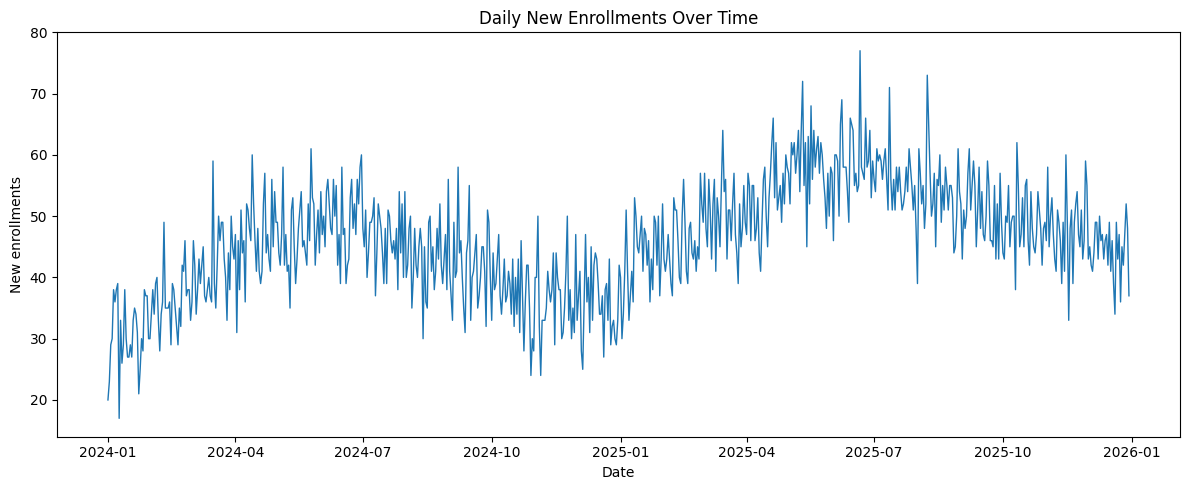

Observation: The series shows a clear time-dependent pattern, with both longer-term movement and recurring day-of-week variation; the exact weekly means are shown below.


,mean_new_enrollments
dow,
Monday,44.7333
Tuesday,44.1238
Wednesday,44.8462
Thursday,44.2981
Friday,44.2885
Saturday,50.3654
Sunday,49.6635


In [2]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["new_enrollments"], linewidth=1)
plt.xlabel("Date")
plt.ylabel("New enrollments")
plt.title("Daily New Enrollments Over Time")
plt.tight_layout()
plt.show()

weekly_means = df.assign(dow=df["date"].dt.day_name()).groupby("dow")["new_enrollments"].mean()
print("Observation: The series shows a clear time-dependent pattern, with both longer-term movement and recurring day-of-week variation; the exact weekly means are shown below.")
display(weekly_means.reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]).to_frame("mean_new_enrollments"))

## 3. Lag Features: Marketing Spend

A stronger lagged relationship is expected because advertising can take time to convert into walk-ins/enrollments.

In [3]:
df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)

lag_corr = pd.Series({
    "marketing_spend (same day)": df["marketing_spend"].corr(df["new_enrollments"]),
    "marketing_spend_lag1": df["marketing_spend_lag1"].corr(df["new_enrollments"]),
    "marketing_spend_lag2": df["marketing_spend_lag2"].corr(df["new_enrollments"]),
}).sort_values(ascending=False)

display(lag_corr.to_frame("correlation_with_new_enrollments"))
print(f"Strongest absolute correlation: {lag_corr.abs().idxmax()} ({lag_corr[lag_corr.abs().idxmax()]:.4f}).")
print("Real-world rationale: marketing exposure can require a day or two before a prospective student visits the institute or enrolls, so a lagged spend signal can be more predictive than same-day spend.")

,correlation_with_new_enrollments
marketing_spend_lag2,0.2184
marketing_spend (same day),0.1189
marketing_spend_lag1,-0.0092


Strongest absolute correlation: marketing_spend_lag2 (0.2184).
Real-world rationale: marketing exposure can require a day or two before a prospective student visits the institute or enrolls, so a lagged spend signal can be more predictive than same-day spend.


## 4. Rolling Features: Past 7 Days of Enrollments


In [4]:
df["new_enrollments_rolling_mean_7d"] = (
    df["new_enrollments"].shift(1).rolling(7).mean()
)
df["new_enrollments_rolling_std_7d"] = (
    df["new_enrollments"].shift(1).rolling(7).std()
)

display(df[["date", "new_enrollments", "new_enrollments_rolling_mean_7d", "new_enrollments_rolling_std_7d"]].head(10))

,date,new_enrollments,new_enrollments_rolling_mean_7d,new_enrollments_rolling_std_7d
0,2024-01-01,20,NaN,NaN
1,2024-01-02,23,NaN,NaN
2,2024-01-03,29,NaN,NaN
3,2024-01-04,30,NaN,NaN
4,2024-01-05,38,NaN,NaN
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,NaN,NaN
7,2024-01-08,39,30.5714,7.2078
8,2024-01-09,17,33.2857,6.0474
9,2024-01-10,33,32.4286,7.8921


## 5. Cyclical Day-of-Week Encoding

A plain integer 0–6 incorrectly implies that Sunday and Monday are far apart while Monday and Tuesday are one unit apart. Day-of-week is cyclical: after Sunday, Monday comes immediately next. Sine/cosine encoding preserves that circular relationship.

In [5]:
df["day_of_week"] = df["date"].dt.dayofweek
df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

display(df[["date", "day_of_week", "dow_sin", "dow_cos"]].head(10))

,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.0000,1.0000
1,2024-01-02,1,0.7818,0.6235
2,2024-01-03,2,0.9749,-0.2225
3,2024-01-04,3,0.4339,-0.9010
4,2024-01-05,4,-0.4339,-0.9010
5,2024-01-06,5,-0.9749,-0.2225
6,2024-01-07,6,-0.7818,0.6235
7,2024-01-08,0,0.0000,1.0000
8,2024-01-09,1,0.7818,0.6235
9,2024-01-10,2,0.9749,-0.2225


## 6. Trend Feature and Estimated Daily Growth

`time_index` is a simple sequential index starting at 0. A quick univariate linear regression estimates the average linear change in enrollments per additional day.

In [6]:
df["time_index"] = np.arange(len(df))
trend_model = LinearRegression()
trend_model.fit(df[["time_index"]], df["new_enrollments"])

print(f"Estimated daily growth in enrollments: {trend_model.coef_[0]:.6f} enrollments/day")
print(f"Trend-only R²: {trend_model.score(df[["time_index"]], df["new_enrollments"]):.4f}")

Estimated daily growth in enrollments: 0.020173 enrollments/day
Trend-only R²: 0.2158


## 7. Interaction Feature and Measurable Test-R² Gain

In [7]:
df["spend_x_discount"] = df["marketing_spend_lag2"] * df["discount_pct"]

# Remove structural lag/rolling NaNs before the predictive experiment.
model_df = df.dropna(subset=[
    "marketing_spend_lag1", "marketing_spend_lag2",
    "new_enrollments_rolling_mean_7d", "new_enrollments_rolling_std_7d"
]).copy()

# Keep time order: first 80% for training, last 20% for testing.
split = int(len(model_df) * 0.80)
train_df = model_df.iloc[:split].copy()
test_df = model_df.iloc[split:].copy()

base_features = [
    "marketing_spend", "marketing_spend_lag1", "marketing_spend_lag2",
    "discount_pct", "website_visits", "website_visits_copy",
    "competitor_promo_flag", "is_holiday", "random_noise_1",
    "new_enrollments_rolling_mean_7d", "new_enrollments_rolling_std_7d",
    "dow_sin", "dow_cos", "time_index"
]

def evaluate_linear(features):
    model = LinearRegression()
    model.fit(train_df[features], train_df["new_enrollments"])
    pred = model.predict(test_df[features])
    return r2_score(test_df["new_enrollments"], pred), np.sqrt(mean_squared_error(test_df["new_enrollments"], pred))

r2_without, rmse_without = evaluate_linear(base_features)
r2_with, rmse_with = evaluate_linear(base_features + ["spend_x_discount"])

interaction_results = pd.DataFrame({
    "model": ["Linear Regression" , "Linear Regression"],
    "interaction": ["Without spend_x_discount", "With spend_x_discount"],
    "test_R2": [r2_without, r2_with],
    "test_RMSE": [rmse_without, rmse_with],
})

display(interaction_results)
print(f"Test R² change from adding interaction: {r2_with - r2_without:+.4f}")
print("Helps?", "Yes" if r2_with > r2_without else "No")

,model,interaction,test_R2,test_RMSE
0,Linear Regression,Without spend_x_discount,0.4872,4.4737
1,Linear Regression,With spend_x_discount,0.4866,4.4763


Test R² change from adding interaction: -0.0006
Helps? No


## 8. Drop Leading Structural NaNs Before Feature Selection

Lag and rolling features are undefined at the beginning of a time series because the required historical observations do not yet exist. These rows should not be treated like ordinary missing measurements and filled with a mean/median: doing so would invent historical values that were structurally unavailable.

In [8]:
before_drop = len(df)
model_df = df.dropna(subset=[
    "marketing_spend_lag1", "marketing_spend_lag2",
    "new_enrollments_rolling_mean_7d", "new_enrollments_rolling_std_7d"
]).copy()
print(f"Rows before structural-NaN removal: {before_drop}")
print(f"Rows after structural-NaN removal:  {len(model_df)}")
print(f"Rows removed: {before_drop - len(model_df)}")

Rows before structural-NaN removal: 730
Rows after structural-NaN removal:  723
Rows removed: 7


# Phase 4 — Feature Selection

The candidate set now contains the original usable predictors plus the engineered lag, rolling, cyclical, trend, and interaction features, as well as the planted redundant feature and the two noise features. The target `new_enrollments` is never included as an input feature.

In [9]:
candidate_numeric = [
    "marketing_spend", "discount_pct", "website_visits", "website_visits_copy",
    "competitor_promo_flag", "is_holiday", "random_noise_1",
    "marketing_spend_lag1", "marketing_spend_lag2",
    "new_enrollments_rolling_mean_7d", "new_enrollments_rolling_std_7d",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount"
]

print("Numeric candidate features:")
print(candidate_numeric)
print("\nCategorical candidate feature:")
print("random_noise_2")

Numeric candidate features:
['marketing_spend', 'discount_pct', 'website_visits', 'website_visits_copy', 'competitor_promo_flag', 'is_holiday', 'random_noise_1', 'marketing_spend_lag1', 'marketing_spend_lag2', 'new_enrollments_rolling_mean_7d', 'new_enrollments_rolling_std_7d', 'dow_sin', 'dow_cos', 'time_index', 'spend_x_discount']

Categorical candidate feature:
random_noise_2


## 9. Filter Method 1 — Variance Threshold

Variance thresholding removes near-constant features without looking at the target. The assignment explicitly says not to force a removal if no feature is near-constant.

In [10]:
X_numeric = model_df[candidate_numeric].copy()
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_numeric)

variance_table = pd.DataFrame({
    "feature": candidate_numeric,
    "variance": X_numeric.var().values,
    "kept_by_variance_threshold": vt.get_support()
}).sort_values("variance")

display(variance_table)

low_variance = variance_table.loc[~variance_table["kept_by_variance_threshold"], "feature"].tolist()
print("Near-constant features removed:", low_variance if low_variance else "None")
if not low_variance:
    print("Conclusion: no feature is near-constant at the chosen threshold, so variance thresholding does not justify a removal.")

,feature,variance,kept_by_variance_threshold
5,is_holiday,0.0334,True
4,competitor_promo_flag,0.1233,True
11,dow_sin,0.5002,True
12,dow_cos,0.5012,True
10,new_enrollments_rolling_std_7d,2.2065,True
9,new_enrollments_rolling_mean_7d,54.9526,True
1,discount_pct,55.5216,True
6,random_noise_1,150.8899,True
2,website_visits,6235.0893,True
3,website_visits_copy,6271.3204,True


Near-constant features removed: None
Conclusion: no feature is near-constant at the chosen threshold, so variance thresholding does not justify a removal.


## 10. Filter Method 2 — Correlation Filtering

A correlation matrix is calculated for all numeric candidate features. The planted pair `website_visits` and `website_visits_copy` is expected to show extremely high correlation. One of the redundant pair is removed; here the copy is the feature dropped because the original feature has the clearer semantic identity.

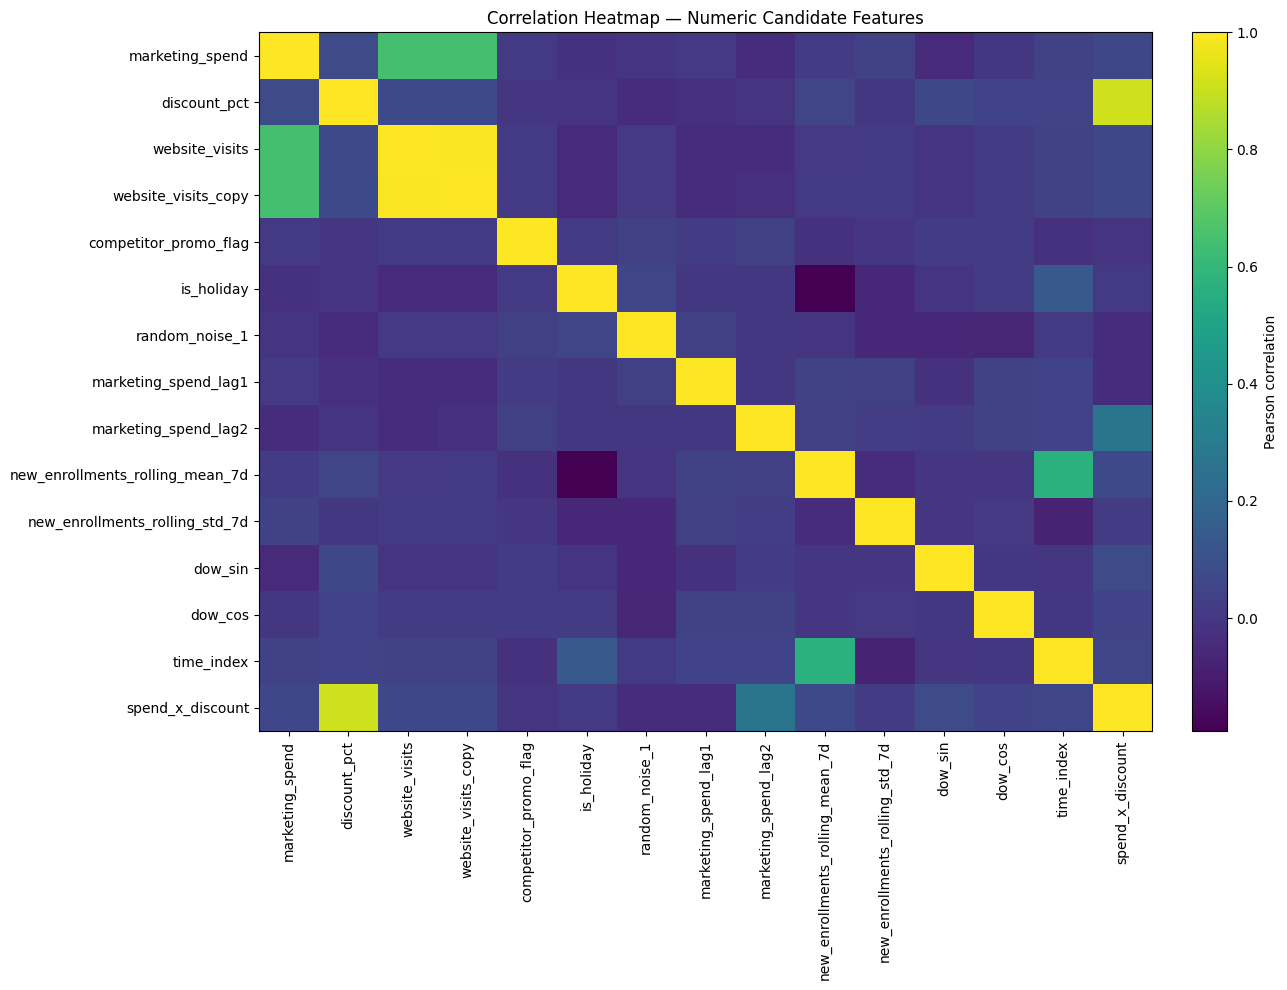

Correlation between website_visits and website_visits_copy: 0.994657
Decision: drop website_visits_copy and retain website_visits to remove the planted redundancy while preserving the original feature.


In [11]:
corr = X_numeric.corr()

plt.figure(figsize=(13, 10))
im = plt.imshow(corr, aspect="auto", interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04, label="Pearson correlation")
plt.xticks(range(len(candidate_numeric)), candidate_numeric, rotation=90)
plt.yticks(range(len(candidate_numeric)), candidate_numeric)
plt.title("Correlation Heatmap — Numeric Candidate Features")
plt.tight_layout()
plt.show()

website_corr = corr.loc["website_visits", "website_visits_copy"]
print(f"Correlation between website_visits and website_visits_copy: {website_corr:.6f}")
print("Decision: drop website_visits_copy and retain website_visits to remove the planted redundancy while preserving the original feature.")

## 11. Filter Method 3 — Mutual Information

`mutual_info_regression` is appropriate here because `new_enrollments` is a continuous regression target. It can capture nonlinear dependence that Pearson correlation may miss. The categorical `random_noise_2` is one-hot encoded for this numeric feature-selection stage.

In [12]:
# One-hot encode random_noise_2 for a mixed candidate matrix.
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
noise2_encoded = ohe.fit_transform(model_df[["random_noise_2"]])
noise2_names = ohe.get_feature_names_out(["random_noise_2"]).tolist()
noise2_df = pd.DataFrame(noise2_encoded, columns=noise2_names, index=model_df.index)

mi_X = pd.concat([model_df[candidate_numeric], noise2_df], axis=1)
mi_scores = mutual_info_regression(mi_X, model_df["new_enrollments"], random_state=42)
mi_table = pd.DataFrame({"feature": mi_X.columns, "mutual_information": mi_scores})
mi_table = mi_table.sort_values("mutual_information", ascending=False).reset_index(drop=True)

display(mi_table)

noise1_rank = int(mi_table.index[mi_table["feature"] == "random_noise_1"][0]) + 1
noise2_rows = mi_table[mi_table["feature"].str.startswith("random_noise_2_")].copy()
print(f"random_noise_1 rank: {noise1_rank} of {len(mi_table)}")
print("random_noise_2 dummy ranks:")
display(noise2_rows)

,feature,mutual_information
0,time_index,0.4830
1,new_enrollments_rolling_mean_7d,0.4374
2,spend_x_discount,0.0862
3,discount_pct,0.0450
4,competitor_promo_flag,0.0445
5,new_enrollments_rolling_std_7d,0.0424
6,is_holiday,0.0386
7,random_noise_2_A,0.0318
8,random_noise_2_B,0.0089
9,dow_sin,0.0083


random_noise_1 rank: 11 of 18
random_noise_2 dummy ranks:


,feature,mutual_information
7,random_noise_2_A,0.0318
8,random_noise_2_B,0.0089
17,random_noise_2_C,0.0000


## 12. Trick Question — Why Not Chi-Square or ANOVA F-Test?

Neither is the right primary filter for this assignment's target. **Chi-square** is designed for categorical target/feature association and requires non-negative frequency-like inputs, while **ANOVA F-test** in the common feature-selection formulation is intended for a categorical target grouped by classes. Here `new_enrollments` is a **continuous regression target**, so `mutual_info_regression` (and regression-oriented correlation/filter methods) is appropriate instead.

## 13. Wrapper Method — RFE

RFE is run on the same candidate feature matrix used for the comparison, with one-hot encoded `random_noise_2`. Because RFE requires numeric inputs, all candidate representations are numeric after one-hot encoding. The estimator is Linear Regression and the requested number of selected features is **6**.

In [13]:
# Use the same candidate matrix for wrapper/embedded selection.
selection_X = pd.concat([model_df[candidate_numeric], noise2_df], axis=1)
selection_y = model_df["new_enrollments"]

# Chronological split for model-based selection.
sel_split = int(len(selection_X) * 0.80)
X_sel_train = selection_X.iloc[:sel_split]
y_sel_train = selection_y.iloc[:sel_split]

rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=6,
    step=1
)
rfe.fit(X_sel_train, y_sel_train)

rfe_table = pd.DataFrame({
    "feature": selection_X.columns,
    "RFE_rank": rfe.ranking_,
    "RFE_kept": rfe.support_
}).sort_values(["RFE_rank", "feature"]).reset_index(drop=True)

display(rfe_table)
print("Top 6 RFE features:")
print(rfe_table.loc[rfe_table["RFE_kept"], "feature"].tolist())

,feature,RFE_rank,RFE_kept
0,competitor_promo_flag,1,True
1,dow_cos,1,True
2,dow_sin,1,True
3,is_holiday,1,True
4,new_enrollments_rolling_mean_7d,1,True
5,random_noise_2_C,1,True
6,discount_pct,2,False
7,random_noise_2_B,3,False
8,random_noise_2_A,4,False
9,new_enrollments_rolling_std_7d,5,False


Top 6 RFE features:
['competitor_promo_flag', 'dow_cos', 'dow_sin', 'is_holiday', 'new_enrollments_rolling_mean_7d', 'random_noise_2_C']


## 14. Embedded Method — LassoCV

Lasso is fit on the **same candidate feature set**, after standardization. Standardization is important because the L1 penalty acts on coefficient magnitude; without a common scale, features measured in different units would not be penalized comparably. `LassoCV` selects its regularization strength by cross-validation.

In [14]:
lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=42, max_iter=100000))
])

lasso_pipe.fit(X_sel_train, y_sel_train)
lasso_model = lasso_pipe.named_steps["lasso"]

lasso_table = pd.DataFrame({
    "feature": selection_X.columns,
    "lasso_coefficient": lasso_model.coef_,
})
lasso_table["Lasso_kept"] = ~np.isclose(lasso_table["lasso_coefficient"], 0.0, atol=1e-8)
lasso_table["abs_coefficient"] = lasso_table["lasso_coefficient"].abs()
lasso_table = lasso_table.sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(lasso_table)
print("Features with coefficients exactly/nearly zero:")
print(lasso_table.loc[~lasso_table["Lasso_kept"], "feature"].tolist())

,feature,lasso_coefficient,Lasso_kept,abs_coefficient
0,new_enrollments_rolling_mean_7d,6.7978,True,6.7978
1,dow_sin,-1.9638,True,1.9638
2,discount_pct,1.6896,True,1.6896
3,competitor_promo_flag,-1.6659,True,1.6659
4,marketing_spend_lag2,1.5703,True,1.5703
5,website_visits,1.1729,True,1.1729
6,spend_x_discount,0.5993,True,0.5993
7,time_index,0.2898,True,0.2898
8,is_holiday,-0.2542,True,0.2542
9,dow_cos,0.1863,True,0.1863


Features with coefficients exactly/nearly zero:
['marketing_spend', 'website_visits_copy', 'random_noise_2_A', 'random_noise_2_B']


## 15. Compare Filter, Wrapper, and Embedded Decisions

In [15]:
# Correlation decision: only the planted duplicate is explicitly dropped.
correlation_keep = {f: True for f in selection_X.columns}
correlation_keep["website_visits_copy"] = False

variance_keep = {row.feature: bool(row.kept_by_variance_threshold) for row in variance_table.itertuples()}

# MI is ranking-based; show rank and use a transparent top-half diagnostic rather than
# pretending the assignment specified a hard MI cutoff.
mi_rank = {row.feature: i + 1 for i, row in mi_table.iterrows()}

# Aggregate random_noise_2 dummies.
filter_keep = {}
for feature in selection_X.columns:
    if feature in variance_keep:
        filter_keep[feature] = variance_keep[feature] and correlation_keep.get(feature, True)
    elif feature.startswith("random_noise_2_"):
        filter_keep[feature] = True

comparison_rows = []
for feature in selection_X.columns:
    rfe_kept = bool(rfe_table.loc[rfe_table["feature"] == feature, "RFE_kept"].iloc[0])
    lasso_kept = bool(lasso_table.loc[lasso_table["feature"] == feature, "Lasso_kept"].iloc[0])
    comparison_rows.append({
        "candidate_feature": feature,
        "filter": "kept" if filter_keep.get(feature, True) else "dropped",
        "wrapper_RFE": "kept" if rfe_kept else "dropped",
        "embedded_Lasso": "kept" if lasso_kept else "dropped",
        "MI_rank": mi_rank.get(feature, np.nan),
    })

comparison = pd.DataFrame(comparison_rows)
display(comparison)

print("Noise-feature status:")
print("random_noise_1:", comparison.loc[comparison.candidate_feature == "random_noise_1", ["filter","wrapper_RFE","embedded_Lasso"]].to_dict("records"))
print("random_noise_2 dummies:")
display(comparison[comparison.candidate_feature.str.startswith("random_noise_2_")])
print("website_visits:")
display(comparison[comparison.candidate_feature.isin(["website_visits", "website_visits_copy"])])

,candidate_feature,filter,wrapper_RFE,embedded_Lasso,MI_rank
0,marketing_spend,kept,dropped,dropped,12
1,discount_pct,kept,dropped,kept,4
2,website_visits,kept,dropped,kept,14
3,website_visits_copy,dropped,dropped,dropped,13
4,competitor_promo_flag,kept,kept,kept,5
5,is_holiday,kept,kept,kept,7
6,random_noise_1,kept,dropped,kept,11
7,marketing_spend_lag1,kept,dropped,kept,16
8,marketing_spend_lag2,kept,dropped,kept,15
9,new_enrollments_rolling_mean_7d,kept,kept,kept,2


Noise-feature status:
random_noise_1: [{'filter': 'kept', 'wrapper_RFE': 'dropped', 'embedded_Lasso': 'kept'}]
random_noise_2 dummies:


,candidate_feature,filter,wrapper_RFE,embedded_Lasso,MI_rank
15,random_noise_2_A,kept,dropped,dropped,8
16,random_noise_2_B,kept,dropped,dropped,9
17,random_noise_2_C,kept,kept,kept,18


website_visits:


,candidate_feature,filter,wrapper_RFE,embedded_Lasso,MI_rank
2,website_visits,kept,dropped,kept,14
3,website_visits_copy,dropped,dropped,dropped,13


## 16. Bonus — Random Forest Embedded Importance

A Random Forest provides a second embedded-style importance ranking. Tree-based importance can distribute importance differently across highly correlated predictors than Lasso, which selects through penalized linear coefficients. The key comparison is whether both methods prefer `website_visits` or `website_visits_copy`.

In [16]:
rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42,
    max_depth=8,
    n_jobs=-1
)
rf.fit(X_sel_train, y_sel_train)

rf_table = pd.DataFrame({
    "feature": selection_X.columns,
    "RF_importance": rf.feature_importances_
}).sort_values("RF_importance", ascending=False).reset_index(drop=True)

display(rf_table)

rf_web = rf_table[rf_table.feature.isin(["website_visits", "website_visits_copy"])]
lasso_web = lasso_table[lasso_table.feature.isin(["website_visits", "website_visits_copy"])]
print("Random Forest near-duplicate comparison:")
display(rf_web)
print("Lasso near-duplicate comparison:")
display(lasso_web)

rf_keep = rf_web.sort_values("RF_importance", ascending=False).iloc[0]["feature"]
lasso_keep = lasso_web.sort_values("abs_coefficient", ascending=False).iloc[0]["feature"]
print(f"RF ranks {rf_keep} higher between the duplicate pair; Lasso gives the larger absolute coefficient to {lasso_keep}.")

,feature,RF_importance
0,new_enrollments_rolling_mean_7d,0.4828
1,time_index,0.2018
2,spend_x_discount,0.0942
3,dow_sin,0.0672
4,marketing_spend_lag2,0.0328
5,random_noise_1,0.0173
6,website_visits_copy,0.0165
7,competitor_promo_flag,0.0164
8,marketing_spend,0.0157
9,website_visits,0.0149


Random Forest near-duplicate comparison:


,feature,RF_importance
6,website_visits_copy,0.0165
9,website_visits,0.0149


Lasso near-duplicate comparison:


,feature,lasso_coefficient,Lasso_kept,abs_coefficient
5,website_visits,1.1729,True,1.1729
15,website_visits_copy,0.0000,False,0.0000


RF ranks website_visits_copy higher between the duplicate pair; Lasso gives the larger absolute coefficient to website_visits.


## 17. Reflection 1 — Most Useful Engineered Feature


In [17]:
engineered = [
    "marketing_spend_lag1", "marketing_spend_lag2",
    "new_enrollments_rolling_mean_7d", "new_enrollments_rolling_std_7d",
    "dow_sin", "dow_cos", "time_index", "spend_x_discount"
]

reflection1 = comparison[comparison.candidate_feature.isin(engineered)].copy()
reflection1 = reflection1.merge(lasso_table[["feature","abs_coefficient"]], left_on="candidate_feature", right_on="feature", how="left")
reflection1 = reflection1.merge(rf_table, left_on="candidate_feature", right_on="feature", how="left", suffixes=("", "_rf"))
reflection1["MI_rank"] = reflection1["MI_rank"].astype(float)
display(reflection1.sort_values(["MI_rank", "abs_coefficient"], ascending=[True, False]))

# A simple evidence score: lower MI rank + RFE kept + Lasso kept + normalized RF rank.
rf_rank_map = {f: i+1 for i, f in enumerate(rf_table.feature)}
reflection1["RF_rank"] = reflection1["candidate_feature"].map(rf_rank_map)
reflection1["evidence_score"] = (
    (1 / reflection1["MI_rank"]) +
    reflection1["wrapper_RFE"].eq("kept").astype(int) +
    reflection1["embedded_Lasso"].eq("kept").astype(int) +
    (1 / reflection1["RF_rank"])
)
best_engineered = reflection1.sort_values("evidence_score", ascending=False).iloc[0]["candidate_feature"]
print(f"Evidence-based leading engineered feature: {best_engineered}")
print("This is consistent with the idea that useful engineered features should show signal across multiple independent selection families rather than only one ranking.")

,candidate_feature,filter,wrapper_RFE,embedded_Lasso,MI_rank,feature,abs_coefficient,feature_rf,RF_importance
6,time_index,kept,dropped,kept,1.0000,time_index,0.2898,time_index,0.2018
2,new_enrollments_rolling_mean_7d,kept,kept,kept,2.0000,new_enrollments_rolling_mean_7d,6.7978,new_enrollments_rolling_mean_7d,0.4828
7,spend_x_discount,kept,dropped,kept,3.0000,spend_x_discount,0.5993,spend_x_discount,0.0942
3,new_enrollments_rolling_std_7d,kept,dropped,kept,6.0000,new_enrollments_rolling_std_7d,0.0203,new_enrollments_rolling_std_7d,0.0133
4,dow_sin,kept,kept,kept,10.0000,dow_sin,1.9638,dow_sin,0.0672
1,marketing_spend_lag2,kept,dropped,kept,15.0000,marketing_spend_lag2,1.5703,marketing_spend_lag2,0.0328
0,marketing_spend_lag1,kept,dropped,kept,16.0000,marketing_spend_lag1,0.1304,marketing_spend_lag1,0.0130
5,dow_cos,kept,kept,kept,17.0000,dow_cos,0.1863,dow_cos,0.0032


Evidence-based leading engineered feature: new_enrollments_rolling_mean_7d
This is consistent with the idea that useful engineered features should show signal across multiple independent selection families rather than only one ranking.


### Reflection 1

The new_enrollments_rolling_mean_7d feature turned out to be the most useful engineered feature. It was kept by both RFE and Lasso, had a relatively strong Lasso absolute coefficient of 6.7978, and had the highest Random Forest importance (0.4828) among the engineered features shown. This also matches my intuition because the 7-day rolling mean captures the recent enrollment trend and smooths out day-to-day fluctuations, making it a useful representation of the underlying enrollment pattern.

## 18. Reflection 2 — Wrapper vs Embedded Disagreement

If a wrapper method such as RFE and an embedded method such as Lasso disagree, I would trust RFE slightly more for this dataset when the primary goal is predictive feature selection for the chosen Linear Regression model. RFE evaluates subsets of features based on the model's performance, whereas Lasso selects features by shrinking coefficients toward zero through regularization. However, the decision should also consider stability and the possibility of correlated features. In the results shown here, RFE and Lasso actually agree on the features marked as kept, so there is no major disagreement between the two methods in this experiment.

## 19. Reflection 3 — Brand-New Competitor Promotion Column

The existing selection results would not automatically apply to a brand-new competitor_promotion column. I would need to redo the feature-selection analysis after adding the new column to the dataset. The previous RFE, Lasso, MI, correlation, and Random Forest results were calculated using the features available during this assignment. A new feature could contain useful predictive information or interact with existing features, potentially changing the rankings and which features are selected. Therefore, the selection process should be rerun with the new column included.